<a href="https://colab.research.google.com/github/taehi5/Esaa_YB/blob/5%EC%A3%BC%EC%B0%A8-%EA%B3%BC%EC%A0%9C/YB_1009(2)_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C_%ED%8F%89%EA%B0%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 모듈 및 데이터 로드
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

data = load_breast_cancer()

# x, y 데이터 생성
X = data.data

# 악성을 1, 양성을 0으로
y = 1 - data.target

# 특징으로 사용할 데이터를 평균으로 구분하는 10개 열로 축소
X = X[:, :10]

# 로지스틱 회귀 모델 생성
model_lor = LogisticRegression(solver = 'lbfgs')
model_lor.fit(X,y)
y_pred = model_lor.predict(X)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**오차 행렬(혼동 행렬) 생성**

In [ ]:
# 종속 변수와 예측 결과로 혼동 행렬 생성
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
print(cm)
print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')

[[337  20]
 [ 30 182]]
TN=337, FP=20, FN=30, TP=182


**정확도의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

정확도 = (TP+TN) / 전체 표본수
 => 즉 전체에서 정답을 맞힌 비율
 - 클래스가 불균형하면 정확도만으로 성능을 판단하기 어렵다.

 ➡ 정확도는 약 91.21%로, 전체 569개 중 519개를 올바르게 분류했다.

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y, y_pred)
print(accuracy)

0.9121265377855887


**정밀도의 개념을 설명하고, 정밀도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

정밀도 : 악성이라고 예측한 표본 중 실제 악성인 비율
- 높을수록 악성으로 잘못 판단하는 비율이 낮다.

In [ ]:
from sklearn.metrics import precision_score
precision = precision_score(y, y_pred)
print(precision)

0.900990099009901


➡ 악성으로 예측한 202개 중 실제 악성은 182개이다.

**재현율의 개념을 설명하고, 재현율을 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

재현율 : 실제 악성 중 악성으로 찾아낸 비율
- 낮으면 놓친 악성이 많다는 의미


In [ ]:
from sklearn.metrics import recall_score
recall = recall_score(y, y_pred)
print(recall)

0.8584905660377359


➡ 실제 악성 212개 중 182개를 찾아냈고, 30개를 놓침

**F1 score의 개념을 설명하고, 정확도를 구해 해당 값을 통해 알 수 있는 점을 쓰시오.**

F1 = 2 × 정밀도 × 재현율 / (정밀도 + 재현율)=  2TP / (2TP + FP + FN)
 - 둘 중 하나가 낮으면 F1도 낮아진다.
 - 정밀도와 재현율을 함께 반영하는 조화평균

In [ ]:
from sklearn.metrics import f1_score
f1 = f1_score(y, y_pred)
print(f1)

0.8792270531400966


**예측 확률(pred_proba) : 0으로 예측할 확률이 0.1보다 크면 y_pred2 에 넣는다 가정.**

In [ ]:
from sklearn.preprocessing import Binarizer


In [22]:
# y과 y_pred2의 혼동행렬, 정확도, 정밀도, 재현율, f1 score 구하기
# 예측 확률 구하기 → [0일 확률, 1일 확률] 두 열이 나옴
pred_proba = model_lor.predict_proba(X)

# 0으로 예측할 확률 = 0번째 열 → 2차원으로 reshape
pred_proba_0 = pred_proba[:, 0].reshape(-1, 1)

# 0.1보다 크면 1, 아니면 0
binarizer = Binarizer(threshold=0.1)
y_pred2 = (1 - binarizer.fit_transform(pred_proba_0)).ravel().astype(int)

# y과 y_pred2의 혼동행렬, 정확도, 정밀도, 재현율, f1 score
print('혼동행렬:\n', confusion_matrix(y, y_pred2))
print('정확도:', accuracy_score(y, y_pred2))
print('정밀도:', precision_score(y, y_pred2))
print('재현율:', recall_score(y, y_pred2))
print('F1 score:', f1_score(y, y_pred2))


혼동행렬:
 [[356   1]
 [ 73 139]]
정확도: 0.8699472759226714
정밀도: 0.9928571428571429
재현율: 0.6556603773584906
F1 score: 0.7897727272727273


**ROC 곡선 시각화**

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr

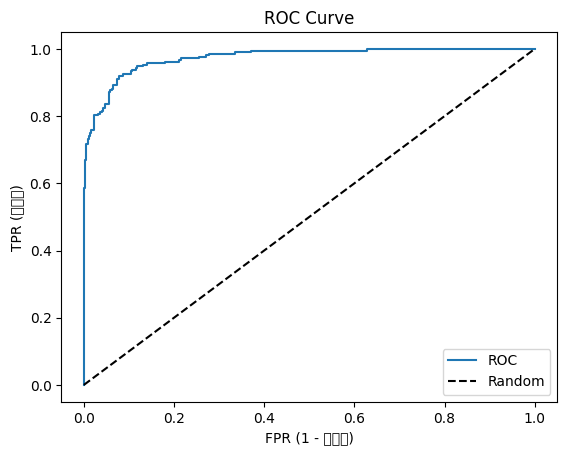

In [23]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
# 1(악성)일 확률로 ROC 곡선 계산
fpr, tpr, thresholds = roc_curve(y, pred_proba[:, 1])

plt.plot(fpr, tpr, label='ROC')
plt.plot([0, 1], [0, 1], 'k--', label='Random')   # 기준선(랜덤 분류)
plt.xlabel('FPR (1 - 특이도)')
plt.ylabel('TPR (재현율)')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [24]:
import matplotlib.pyplot as plt


**ROC AUC 값을 구하고 해당 값을 통해 알 수 있는 점을 쓰시오.**

In [25]:
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y, pred_proba[:, 1])
print('ROC AUC:', roc_auc)

ROC AUC: 0.974076423022039


ROC AUC : ROC 곡선 아래 면적으로, 0.5(랜덤 분류) ~ 1(완벽한 분류) 사이의 값
 - 1에 가까울수록 FPR은 낮게 유지하면서 TPR(재현율)은 높게 얻을 수 있음
 - 임계값 하나가 아니라 모든 임계값에서의 성능을 종합한 지표


➡ ROC AUC = 0.974로 1에 매우 가까움
 - 무작위로 뽑은 악성 1명과 양성 1명 중 모델이 악성에 더 높은 확률을 줄 확률이 약 97.4%라는 의미
 - 임계값을 어떻게 정하더라도 모델이 악성과 양성을 잘 구분하는 좋은 모델이라고 볼 수 있음
 - 따라서 모델 자체의 성능은 충분하고, 악성을 놓치지 않는 것이 중요하다면 임계값을 낮춰 재현율을 높이는 방식으로 활용할 수 있음